This file has car sell prices for 3 different models. First plot data points on a scatter plot chart
to see if linear regression model can be applied. If yes, then build a model that can answer
following questions,

**1) Predict price of a mercedez benz that is 4 yr old with mileage 45000**

**2) Predict price of a BMW X5 that is 7 yr old with mileage 86000**

**3) Tell me the score (accuracy) of your model. (Hint: use LinearRegression().score())**

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv(r"E:\1_Data_Science\Machine-Learning-Projects\19. One_Hot_Encoding\Exercise\carprices.csv")
print(df)


                Car Model  Mileage  Sell Price($)  Age(yrs)
0                  BMW X5    69000          18000         6
1                  BMW X5    35000          34000         3
2                  BMW X5    57000          26100         5
3                  BMW X5    22500          40000         2
4                  BMW X5    46000          31500         4
5                 Audi A5    59000          29400         5
6                 Audi A5    52000          32000         5
7                 Audi A5    72000          19300         6
8                 Audi A5    91000          12000         8
9   Mercedez Benz C class    67000          22000         6
10  Mercedez Benz C class    83000          20000         7
11  Mercedez Benz C class    79000          21000         7
12  Mercedez Benz C class    59000          33000         5


In [3]:
df.columns = ['car_model', 'mileage', 'sell_price', 'age']
df

,car_model,mileage,sell_price,age
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4
5,Audi A5,59000,29400,5
6,Audi A5,52000,32000,5
7,Audi A5,72000,19300,6
8,Audi A5,91000,12000,8
9,Mercedez Benz C class,67000,22000,6


Text(0, 0.5, 'Sell Price')

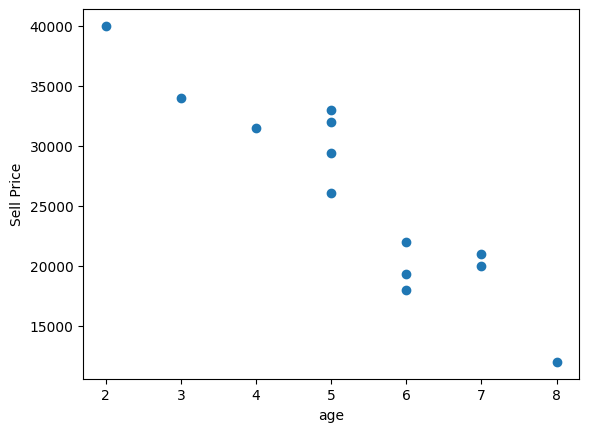

In [4]:
%matplotlib inline
plt.scatter(df.age, df.sell_price)
plt.xlabel("age")
plt.ylabel("Sell Price")

Text(0, 0.5, 'mileage')

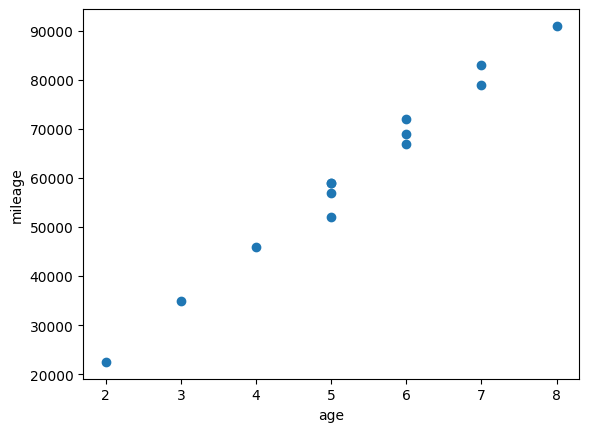

In [5]:
%matplotlib inline
plt.scatter(df.age, df.mileage)
plt.xlabel("age")
plt.ylabel("mileage")

In [6]:
df.columns

Index(['car_model', 'mileage', 'sell_price', 'age'], dtype='object')

In [7]:
dummies = pd.get_dummies(df.car_model, dtype=int)
dummies

,Audi A5,BMW X5,Mercedez Benz C class
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0
5,1,0,0
6,1,0,0
7,1,0,0
8,1,0,0
9,0,0,1


In [8]:
merged = pd.concat([df, dummies], axis='columns')
merged

,car_model,mileage,sell_price,age,Audi A5,BMW X5,Mercedez Benz C class
0,BMW X5,69000,18000,6,0,1,0
1,BMW X5,35000,34000,3,0,1,0
2,BMW X5,57000,26100,5,0,1,0
3,BMW X5,22500,40000,2,0,1,0
4,BMW X5,46000,31500,4,0,1,0
5,Audi A5,59000,29400,5,1,0,0
6,Audi A5,52000,32000,5,1,0,0
7,Audi A5,72000,19300,6,1,0,0
8,Audi A5,91000,12000,8,1,0,0
9,Mercedez Benz C class,67000,22000,6,0,0,1


In [9]:
final = merged.drop(['car_model', 'Mercedez Benz C class'], axis='columns')
final 

,mileage,sell_price,age,Audi A5,BMW X5
0,69000,18000,6,0,1
1,35000,34000,3,0,1
2,57000,26100,5,0,1
3,22500,40000,2,0,1
4,46000,31500,4,0,1
5,59000,29400,5,1,0
6,52000,32000,5,1,0
7,72000,19300,6,1,0
8,91000,12000,8,1,0
9,67000,22000,6,0,0


In [10]:
X = final.drop('sell_price', axis='columns')
X

,mileage,age,Audi A5,BMW X5
0,69000,6,0,1
1,35000,3,0,1
2,57000,5,0,1
3,22500,2,0,1
4,46000,4,0,1
5,59000,5,1,0
6,52000,5,1,0
7,72000,6,1,0
8,91000,8,1,0
9,67000,6,0,0


In [11]:
y = final["sell_price"]
y

0     18000
1     34000
2     26100
3     40000
4     31500
5     29400
6     32000
7     19300
8     12000
9     22000
10    20000
11    21000
12    33000
Name: sell_price, dtype: int64

In [12]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [13]:
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
model.score(X, y)

0.9417050937281082

In [15]:
model.predict(X)

array([18705.2723644 , 35286.78445645, 24479.19112468, 41245.76426391,
       29882.98779056, 28023.6135243 , 30614.46818502, 21879.57266964,
       12182.34562104, 26183.72387884, 18929.31674102, 20409.80511857,
       30477.15426156])

In [16]:
X

,mileage,age,Audi A5,BMW X5
0,69000,6,0,1
1,35000,3,0,1
2,57000,5,0,1
3,22500,2,0,1
4,46000,4,0,1
5,59000,5,1,0
6,52000,5,1,0
7,72000,6,1,0
8,91000,8,1,0
9,67000,6,0,0



**1) Predict price of a mercedez benz that is 4 yr old with mileage 45000**

**2) Predict price of a BMW X5 that is 7 yr old with mileage 86000**

**3) Tell me the score (accuracy) of your model. (Hint: use LinearRegression().score())**

In [17]:
model.predict([[4500, 4, 0, 0]])

e:\1_Data_Science\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([51981.26203334])

In [18]:
model.predict([[8600, 7, 0, 1]])

e:\1_Data_Science\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([39728.19323785])

### Using SKlearn one hot encoder 

First step is to use Label Encoder to convert car model into numbers. 

In [19]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [20]:
df

,car_model,mileage,sell_price,age
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4
5,Audi A5,59000,29400,5
6,Audi A5,52000,32000,5
7,Audi A5,72000,19300,6
8,Audi A5,91000,12000,8
9,Mercedez Benz C class,67000,22000,6


In [21]:
dfle = df 
dfle.car_model=le.fit_transform(dfle.car_model)
dfle

,car_model,mileage,sell_price,age
0,1,69000,18000,6
1,1,35000,34000,3
2,1,57000,26100,5
3,1,22500,40000,2
4,1,46000,31500,4
5,0,59000,29400,5
6,0,52000,32000,5
7,0,72000,19300,6
8,0,91000,12000,8
9,2,67000,22000,6


##### To convert into 2d array use .value
Machine Learning models:

Do NOT work directly with pandas dataframes

Expect input as NumPy arrays or matrices

So this prepares the input features (X) for training.

In [22]:
X = dfle[['car_model', 'age', 'mileage']].values

In [23]:
X

array([[    1,     6, 69000],
       [    1,     3, 35000],
       [    1,     5, 57000],
       [    1,     2, 22500],
       [    1,     4, 46000],
       [    0,     5, 59000],
       [    0,     5, 52000],
       [    0,     6, 72000],
       [    0,     8, 91000],
       [    2,     6, 67000],
       [    2,     7, 83000],
       [    2,     7, 79000],
       [    2,     5, 59000]], dtype=int64)

In [24]:
y = dfle['sell_price'].values
y

array([18000, 34000, 26100, 40000, 31500, 29400, 32000, 19300, 12000,
       22000, 20000, 21000, 33000], dtype=int64)

Now use one hot encoder to create a dummy variables for each of the car_model

In [25]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer([('car_model', OneHotEncoder(), [0])], remainder='passthrough')

In [26]:
X = ct.fit_transform(X)

In [27]:
X

array([[0.00e+00, 1.00e+00, 0.00e+00, 6.00e+00, 6.90e+04],
       [0.00e+00, 1.00e+00, 0.00e+00, 3.00e+00, 3.50e+04],
       [0.00e+00, 1.00e+00, 0.00e+00, 5.00e+00, 5.70e+04],
       [0.00e+00, 1.00e+00, 0.00e+00, 2.00e+00, 2.25e+04],
       [0.00e+00, 1.00e+00, 0.00e+00, 4.00e+00, 4.60e+04],
       [1.00e+00, 0.00e+00, 0.00e+00, 5.00e+00, 5.90e+04],
       [1.00e+00, 0.00e+00, 0.00e+00, 5.00e+00, 5.20e+04],
       [1.00e+00, 0.00e+00, 0.00e+00, 6.00e+00, 7.20e+04],
       [1.00e+00, 0.00e+00, 0.00e+00, 8.00e+00, 9.10e+04],
       [0.00e+00, 0.00e+00, 1.00e+00, 6.00e+00, 6.70e+04],
       [0.00e+00, 0.00e+00, 1.00e+00, 7.00e+00, 8.30e+04],
       [0.00e+00, 0.00e+00, 1.00e+00, 7.00e+00, 7.90e+04],
       [0.00e+00, 0.00e+00, 1.00e+00, 5.00e+00, 5.90e+04]])

In [28]:
X = X[:, 1:]

In [29]:
X

array([[1.00e+00, 0.00e+00, 6.00e+00, 6.90e+04],
       [1.00e+00, 0.00e+00, 3.00e+00, 3.50e+04],
       [1.00e+00, 0.00e+00, 5.00e+00, 5.70e+04],
       [1.00e+00, 0.00e+00, 2.00e+00, 2.25e+04],
       [1.00e+00, 0.00e+00, 4.00e+00, 4.60e+04],
       [0.00e+00, 0.00e+00, 5.00e+00, 5.90e+04],
       [0.00e+00, 0.00e+00, 5.00e+00, 5.20e+04],
       [0.00e+00, 0.00e+00, 6.00e+00, 7.20e+04],
       [0.00e+00, 0.00e+00, 8.00e+00, 9.10e+04],
       [0.00e+00, 1.00e+00, 6.00e+00, 6.70e+04],
       [0.00e+00, 1.00e+00, 7.00e+00, 8.30e+04],
       [0.00e+00, 1.00e+00, 7.00e+00, 7.90e+04],
       [0.00e+00, 1.00e+00, 5.00e+00, 5.90e+04]])

In [30]:
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False



**1) Predict price of a mercedez benz that is 4 yr old with mileage 45000**

**2) Predict price of a BMW X5 that is 7 yr old with mileage 86000**

**3) Tell me the score (accuracy) of your model. (Hint: use LinearRegression().score())**

In [31]:
X

array([[1.00e+00, 0.00e+00, 6.00e+00, 6.90e+04],
       [1.00e+00, 0.00e+00, 3.00e+00, 3.50e+04],
       [1.00e+00, 0.00e+00, 5.00e+00, 5.70e+04],
       [1.00e+00, 0.00e+00, 2.00e+00, 2.25e+04],
       [1.00e+00, 0.00e+00, 4.00e+00, 4.60e+04],
       [0.00e+00, 0.00e+00, 5.00e+00, 5.90e+04],
       [0.00e+00, 0.00e+00, 5.00e+00, 5.20e+04],
       [0.00e+00, 0.00e+00, 6.00e+00, 7.20e+04],
       [0.00e+00, 0.00e+00, 8.00e+00, 9.10e+04],
       [0.00e+00, 1.00e+00, 6.00e+00, 6.70e+04],
       [0.00e+00, 1.00e+00, 7.00e+00, 8.30e+04],
       [0.00e+00, 1.00e+00, 7.00e+00, 7.90e+04],
       [0.00e+00, 1.00e+00, 5.00e+00, 5.90e+04]])

#### format 'car_model', 'age', 'mileage'

**input**
**column 0: BMW (1 or 0)**
**column 1: Mercedez Benz (1 or 0)**
**column 2: Age (years)**
**column 3: Mileage**

**Example from input array**
**bmw [1, 0, 6, 6900]**


**1) Predict price of a mercedez benz that is 4 yr old with mileage 45000**

**2) Predict price of a BMW X5 that is 7 yr old with mileage 86000**

**3) Tell me the score (accuracy) of your model. (Hint: use LinearRegression().score())**

#### Example from input array

In [32]:
#### Predict price of a mercedez benz that is 4 yr old with mileage 45000**
model.predict([[0, 1, 4, 45000]])

array([36991.31721061])

In [33]:
#### Predict price of a BMW X5 that is 7 yr old with mileage 86000**
model.predict([[1, 0, 7, 86000]])

array([11080.74313219])

In [34]:
# model score accuray 
model.score(X, y)

0.9417050937281082